# CNN for images

In [2]:
import numpy as np
import pandas as pd

### Load split data

In [3]:
train_df = pd.read_csv(
    "data/train_df.csv",
    parse_dates=["publish_timestamp"]  # converts datestime string into datetime object
)
test_df = pd.read_csv(
    "data/test_df.csv",
    parse_dates=["publish_timestamp"]
)

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1471 entries, 0 to 1470
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_id                   1471 non-null   int64         
 1   following                 1471 non-null   int64         
 2   publish_timestamp         1471 non-null   datetime64[ns]
 3   has_location              1471 non-null   int64         
 4   is_carousel               1471 non-null   int64         
 5   num_images                1471 non-null   int64         
 6   is_sponsored              1471 non-null   int64         
 7   image_path                1471 non-null   object        
 8   caption                   1443 non-null   object        
 9   follower_following_ratio  1471 non-null   float64       
 10  hour                      1471 non-null   int64         
 11  day                       1471 non-null   object        
 12  is_weekend          

In [5]:
y_train = train_df["engagement_label"].values

y_test = test_df["engagement_label"].values

### Obtain images

In [6]:
train_df['image_path'].value_counts()

image_path
.\datasets\Data\hardikpandya93_25298326_3015497697586924812_1434924_4335\2023-01-14_11-22-39_UTC.jpg    1
.\datasets\Data\minimalistbaker_2144759_3030046787029914286_2685_25\2023-02-03_13-09-06_UTC_1.jpg       1
.\datasets\Data\minimalistbaker_2144759_3020624944770383934_2613_21\2023-01-21_13-09-35_UTC_1.jpg       1
.\datasets\Data\minimalistbaker_2144759_3019891519067395807_2740_30\2023-01-20_12-52-24_UTC_1.jpg       1
.\datasets\Data\minimalistbaker_2144759_3015554073848571245_2872_20\2023-01-14_13-14-40_UTC_1.jpg       1
                                                                                                       ..
.\datasets\Data\brendonburchard_1158797_3044039991576878179_3441_88\2023-02-22_20-31-06_UTC.jpg         1
.\datasets\Data\brendonburchard_1158797_3043283406079789678_2363_62\2023-02-21_19-27-54_UTC_1.jpg       1
.\datasets\Data\brendonburchard_1158797_3042986395971590589_2528_64\2023-02-21_09-37-48_UTC.jpg         1
.\datasets\Data\brendonburchard_115

### Show an example image

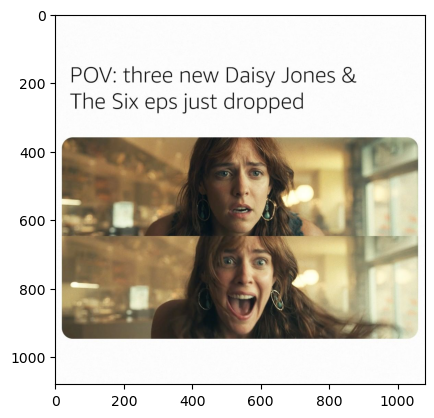

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_image(image_path):
    image = mpimg.imread(image_path)
    plt.imshow(image)

show_image(np.random.choice(train_df['image_path'].unique()))

### Define image transforms

In [8]:
from torchvision import transforms

IMAGE_SIZE = 224  # ResNet expects 224x224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),   # data augmentation
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],        # ImageNet mean
        std=[0.229, 0.224, 0.225]          # ImageNet std
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


### Create Image Dataset class

In [32]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

class ImageDataset(Dataset):
    def __init__(self, df, img_col="image_path", target_col="engagement_label", transform=None):
        self.df = df.reset_index(drop=True)
        self.img_col = img_col
        self.target_col = target_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # print("Loading image:", self.df.iloc[idx]['image_path'])
        img_path = self.df.loc[idx, self.img_col]
        label = self.df.loc[idx, self.target_col]

        # Load image
        img = Image.open(img_path).convert("RGB")  # make sure it's RGB
        
        if self.transform:
            img = self.transform(img)
        
        return img, label


In [33]:
train_ds = ImageDataset(train_df, transform=train_transform)
test_ds  = ImageDataset(test_df, transform=test_transform)

### DataLoader

In [34]:
batch_size = 32

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True, # only for training
    num_workers=0
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)


In [35]:
# import torch.nn as nn
# import torch.nn.functional as F

# class SimpleCNN(nn.Module):
#     def __init__(self, num_classes=3):
#         super().__init__()
#         self.conv1 = nn.Conv2d(3, 32, 3, padding=1)  # input 3 channels (RGB)
#         self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
#         self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
#         self.pool = nn.MaxPool2d(2,2)
#         self.dropout = nn.Dropout(0.3)
#         self.fc1 = nn.Linear(128 * 16 * 16, 256)  # adjust if image_size changes
#         self.fc2 = nn.Linear(256, num_classes)

#     def forward(self, x):
#         x = F.relu(self.conv1(x))
#         x = self.pool(x)
#         x = F.relu(self.conv2(x))
#         x = self.pool(x)
#         x = F.relu(self.conv3(x))
#         x = self.pool(x)  # final size (batch, 128, 16,16) if image_size=128
#         x = x.view(x.size(0), -1)
#         x = self.dropout(F.relu(self.fc1(x)))
#         x = self.fc2(x)
#         return x


In [36]:
# device = "cuda" if torch.cuda.is_available() else "cpu"
# model = SimpleCNN(num_classes=3).to(device)
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


### Pretrained ResNet18 for images

In [37]:
import torch.nn as nn 
import torchvision.models as models
import torch.nn.functional as F

resnet = models.resnet18(weights="IMAGENET1K_V1")

class ImageResNet(nn.Module):
    def __init__(self, resnet_model, num_classes=3, dropout=0.5, freeze_resnet=True):
        super().__init__()
        self.resnet = resnet_model
        if freeze_resnet: # Freeze backbone
            for param in self.resnet.parameters():
                param.requires_grad = False
        
        # Replace the final fc layer (classifier head)
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.resnet(x)

# Hyperparameters

device = "cuda" if torch.cuda.is_available() else "cpu"
model = ImageResNet(resnet, num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(
    model.resnet.fc.parameters(), # only train classifier head when frozen
    lr=1e-3
)


### Train and test loop

In [38]:

# training loop
def train_epoch(loader):
    print("Training")
    # Put model in training mode
    model.train()

    # Initialize accumulator for total loss
    total_loss = 0

    # Loops over batches in training set
    for batch in loader:
        # Detect if batch is a dict (BERT-style) or tuple (LSTM/MLP/CNN)
        if isinstance(batch, dict):
            # BERT-style
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids=input_ids, attention_mask=attention_mask)

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            # total_loss += loss.item()
            # correct += (logits.argmax(dim=1) == labels).sum().item()
            # total += labels.size(0)

        else:
            # Tuple-style: (X, y) for LSTM, MLP, CNN
            X, y = batch

            # Move x y to same device
            X, y = X.to(device), y.to(device)

            # Clear old gradients from previous batch
            optimizer.zero_grad()

            # Feeds batch into model, perform forward pass, output logits
            logits = model(X)
            # logits = model(input_ids=X["input_ids"], attention_mask=X["attention_mask"])


            # Compute loss for this batch
            loss = criterion(logits, y)

            # Performs backpropagation: computes gradients of the loss with respect to each model parameter.
            loss.backward()

            # Updates model parameters using those gradients
            optimizer.step()

        # Adds the numeric loss value (converted from a tensor with .item()) to the total loss accumulator.
        total_loss += loss.item()

    # Average loss = total loss / number of batches
    avg_loss = total_loss / len(loader)
    
    return avg_loss




In [39]:
def test_epoch(loader):
    # Set model to evaluation mode. Disables dropout, freezes batchnorm stats
    model.eval()

    # Initialize accumulator for total loss
    total_loss = 0

    with torch.no_grad(): # Disables gradient tracking inside this block.
    # This saves memory and time, since we don’t need gradients for validation.
    # It also ensures the model’s weights won’t accidentally be updated.
        for batch in loader:
            if isinstance(batch, dict):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                logits = model(input_ids=input_ids, attention_mask=attention_mask)
                y = labels
                # total_loss += criterion(logits, labels).item()
            else:
                X, y = batch
                X, y = X.to(device), y.to(device)
    
                logits = model(X)
                # logits = model(input_ids=X["input_ids"], attention_mask=X["attention_mask"])


            total_loss += criterion(logits, y).item()

    # Compute average loss
    avg_loss = total_loss / len(loader)
    
    return avg_loss

In [40]:
from sklearn.metrics import confusion_matrix, f1_score

def evaluate_metrics(loader, model):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            if isinstance(batch, dict):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                logits = model(input_ids=input_ids, attention_mask=attention_mask)
                y = labels
            else:
                X, y = batch
                X, y = X.to(device), y.to(device)

                logits = model(X)
                # logits = model(input_ids=X["input_ids"], attention_mask=X["attention_mask"])

            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    # Accuracy
    correct = sum(p == y for p, y in zip(all_preds, all_labels))
    accuracy = correct / len(all_labels)

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Macro F1
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return accuracy, cm, macro_f1


In [43]:
for epoch in range(10):
    train_loss = train_epoch(train_loader)
    test_loss  = test_epoch(test_loader)

    # Metrics
    train_acc, train_cm, train_macro_f1 = evaluate_metrics(train_loader, model)
    test_acc, test_cm, test_macro_f1 = evaluate_metrics(test_loader, model)

    print(f"\nEpoch {epoch+1}")
    print(f"Train   | loss={train_loss:.4f}, acc={train_acc:.3f}, macro-F1={train_macro_f1:.3f}")
    print(f"Test    | loss={test_loss:.4f}, acc={test_acc:.3f}, macro-F1={test_macro_f1:.3f}")

    print("Train Confusion Matrix:")
    print(train_cm)

    print("Test Confusion Matrix:")
    print(test_cm)


Training

Epoch 1
Train   | loss=1.0558, acc=0.471, macro-F1=0.437
Test    | loss=1.0164, acc=0.489, macro-F1=0.430
Train Confusion Matrix:
[[380  37  45]
 [299  81 116]
 [246  35 232]]
Test Confusion Matrix:
[[120  14  13]
 [ 72  16  26]
 [ 58   9  48]]
Training

Epoch 2
Train   | loss=1.0566, acc=0.476, macro-F1=0.429
Test    | loss=1.0710, acc=0.423, macro-F1=0.377
Train Confusion Matrix:
[[134  68 260]
 [ 55 105 336]
 [ 21  31 461]]
Test Confusion Matrix:
[[ 41  22  84]
 [ 17  17  80]
 [  5   9 101]]
Training

Epoch 3
Train   | loss=1.0182, acc=0.511, macro-F1=0.464
Test    | loss=0.9952, acc=0.492, macro-F1=0.440
Train Confusion Matrix:
[[324  22 116]
 [213  66 217]
 [125  26 362]]
Test Confusion Matrix:
[[97 10 40]
 [49 15 50]
 [37  5 73]]
Training

Epoch 4
Train   | loss=1.0245, acc=0.518, macro-F1=0.464
Test    | loss=0.9901, acc=0.484, macro-F1=0.422
Train Confusion Matrix:
[[333  17 112]
 [210  58 228]
 [128  14 371]]
Test Confusion Matrix:
[[98  8 41]
 [52 11 51]
 [38  4 73]